# Simple Neural Network using PyTorch + Lightning
-----

This notebook demonstrates how to implement and train a simple neural network using PyTorch and Lightning.

This simple neural network, as shown below, predicts whether or not a drug dose will be effective.

<img src='images/optimized.png' style='width:720px'>

The training data (below) that the neural network is fit to consist of three data points for three different drug doses. Low (**0**) and high(**1**) doses do not cure a disease, so their y-axis values are both **0**. However, when the dose is **0.5**, that dose can cure the disease, and the corresponding y-axis value is **1**.

<img src='images/training_data_500x275.png' style='width: 250px;'>

Below we can see the output of the neural network for different doses, and it fits the data very well.

<img src='images/training_data_with_bent_shape_500x275.png' style='width: 250px'>

-----

## Import the required modules

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import lightning as L
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

-----

## Build a Simple Neural Network in PyTorch
Building a neural network in **PyTorch** using the **Lightning Module** means creating a new class with two methods: `__init__()` and `forward()`. The `__init__()` method defines and initializes all of the parameters tha we want to use, and the `forward()` method tells **PyTorch** what should happen during a forward pass through the neural network.

The two additional methods `configure_optimizers` and `training_step` are added for use when training the model.

In [25]:
class BasicLightning(L.LightningModule):

    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.bfinal = nn.Parameter(torch.tensor(0.), requires_grad=False)
        
        self.learning_rate = 0.01

    def forward(self, X):
        input_to_top_relu = X * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = X * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = (scaled_top_relu_output + scaled_bottom_relu_output + self.bfinal)

        output = F.relu(input_to_final_relu)
        
        return output

    def configure_optimizers(self):
        return SGD(self.parameters(), self.learning_rate)

    def training_step(self, batch, batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i[0])
        loss = (label_i - output_i)**2

        self.log('train_loss', loss)

        return loss

Once we have created the class that defines the neural network, we can create an actual neural network and print out its parameters.

In [26]:
model = BasicLightning()

print('Paramaters before optimization')
for name, parameter in model.named_parameters():
    print(f'{name} : {parameter.data}')

Paramaters before optimization
w00 : 1.7000000476837158
b00 : -0.8500000238418579
w01 : -40.79999923706055
w10 : 12.600000381469727
b10 : 0.0
w11 : 2.700000047683716
bfinal : 0.0


## Use the Neural Network and Graph the Output
Now that we have a neural network, we can use it on a variety of doses to determine which will be effective. Then we can make a graph of these data, and this graph should match the green bent shape fit to the training data that's shown at the top of this notebook.

In [27]:
input_dosage = torch.linspace(start=0, end=1, steps=11)
input_dosage

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

Now that we have `input_doses`, we can run them through the neural netwok and graph the output.

Text(0.5, 0, 'Dose')

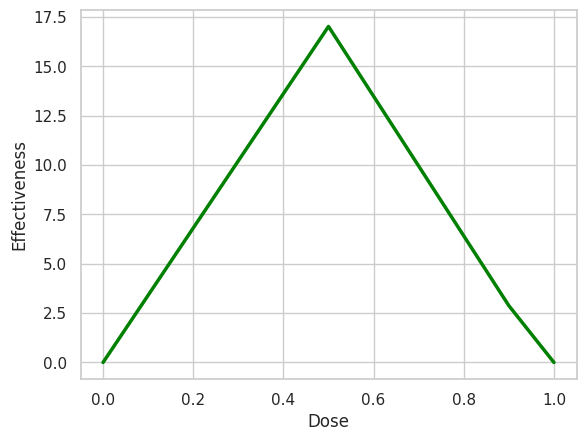

In [28]:
output =  model(input_dosage)

sns.set_theme(style='whitegrid')
sns.lineplot(
    x=input_dosage,
    y=output.detach(),
    color='green',
    linewidth=2.5
)
plt.ylabel('Effectiveness')
plt.xlabel('Dose')

The graph shows that when the dose is **0.5**, the effectiveness is 17, which is wrong, since the output value should be **1**. In other words, so far, our neural network does not fit the data we have provided.

-----

## Optimize (Train) a Parameter in the Neural Network and Graph the Output

In this case, we want to train our neural network. The first thing we need to do is tell **PyTorch** which parameter (or parameters) we want to trai, and we do that by setting `model.bfinal.requires_grad_(True)`. In this example, we'll train `bfinal`.

In [29]:
model.bfinal.requires_grad_(True)

Parameter containing:
tensor(0., requires_grad=True)

So, now that we have a parameter we can optimize, let's create some training data that we can use to optimize it.

In [30]:
inputs = torch.tensor([0., 0.5, 1.])
labels = torch.tensor([0., 1., 0.])

To efficiently feed the inputs to our neural network, we use `TensorDataset` and `DataLoader`

In [31]:
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

Here, we configure `Trainer` to train until `max_epochs` and to find the best learning rate to use for our optimizer.

In [57]:
trainer = L.Trainer(max_epochs=25, accelerator='auto', devices='auto')

tuner = L.pytorch.tuner.Tuner(trainer)

lr_find_results = tuner.lr_find(model,
                                        train_dataloaders=dataloader,
                                        min_lr=0.1,
                                        max_lr=1.0,
                                        early_stop_threshold=None
                                        )

new_lr = lr_find_results.suggestion()

print(f'lr_find() suggests {new_lr:.5f} for the learning rate.')

model.learning_rate = new_lr

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]







`Trainer.fit` stopped: `max_epochs=25` reached.
LR finder stopped early after 75 steps due to diverging loss.
Finding best initial lr:  75%|███████▌  | 75/100 [00:00<00:00, 148.67it/s]
Learning rate set to 0.12882495516931342
Restoring states from the checkpoint path at /home/gabryel/development/ai/pytorch/basics/neuralnet/.lr_find_3394818a-08a1-48ad-b2d2-320c82153cb6.ckpt
Restored all states from the checkpoint at /home/gabryel/development/ai/pytorch/basics/neuralnet/.lr_find_3394818a-08a1-48ad-b2d2-320c82153cb6.ckpt


lr_find() suggests 0.12882 for the learning rate.


In [58]:
print('Paramaters before optimization')
for name, parameter in model.named_parameters():
    print(f'{name} : {parameter.data}')

Paramaters before optimization
w00 : 1.7000000476837158
b00 : -0.8500000238418579
w01 : -40.79999923706055
w10 : 12.600000381469727
b10 : 0.0
w11 : 2.700000047683716
bfinal : -16.0023193359375


...we can now use that training data to train (or optimize) `bfinal`.

In [59]:
trainer.fit(model, train_dataloaders=dataloader)

print('Paramaters after optimization')
for name, parameter in model.named_parameters():
    print(f'{name} : {parameter.data}')

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type | Params
--------------------------------------
  | other params | n/a  | 7     
--------------------------------------
1         Trainable params
6         Non-trainable params
7         Total params
0.000     Total estimated model params size (MB)


Epoch 10:  67%|██████▋   | 2/3 [00:00<00:00, 61.94it/s, v_num=12]

Epoch 24: 100%|██████████| 3/3 [00:00<00:00, 50.22it/s, v_num=12]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 3/3 [00:00<00:00, 36.07it/s, v_num=12]
Paramaters after optimization
w00 : 1.7000000476837158
b00 : -0.8500000238418579
w01 : -40.79999923706055
w10 : 12.600000381469727
b10 : 0.0
w11 : 2.700000047683716
bfinal : -16.00999641418457


The values for each weight and bias in `BasicNN` match the values we see in the neural network (below).

<img src='images/optimized.png' style='width:640px'>

So, if everything worked correctly, the optimizer should have converged on `bfinal = -16.01` after 25 steps, or epochs.

Lastly, let's graph the output from the optimized neural network and see if it's the same as what we expect. If so, then the optimization worked.

Text(0.5, 0, 'Dosage')

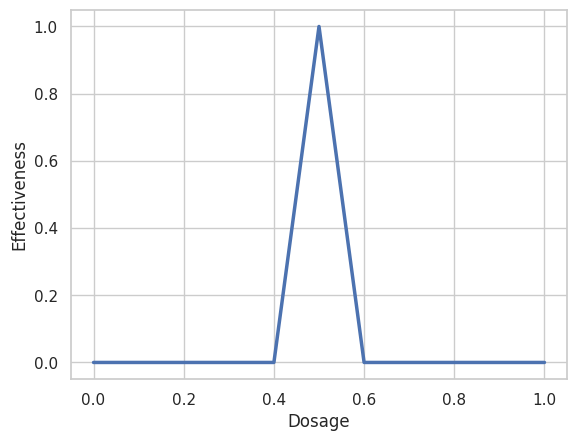

In [61]:
output_trained = model(input_dosage)

sns.set_theme(style='whitegrid')
sns.lineplot(x=input_dosage,
             y=output_trained.detach(),
             linewidth=2.5)
plt.ylabel('Effectiveness')
plt.xlabel('Dosage')